<a href="https://colab.research.google.com/github/mzaib1012/Massive-MIMO-Antenna-Array-Beamforming-and-Spatial-Multiplexing-Simulator/blob/main/notebooks/mimo_beamforming_spatial_multiplexing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Massive MIMO System Parameters ---
N_t = 64            # Number of transmit antenna elements (ULA)
K_users = 4         # Number of users
wavelength = 0.1    # Assuming 3GHz carrier, lambda = 0.1m
d = wavelength / 2  # Half-wavelength spacing

# --- 2. Initialize Array Geometry ---
# Linear antenna positions in a 1D array
ant_pos = np.arange(N_t) * d

# --- 3. Define User Channels ---
# Random angles of arrival/departure (in degrees) for K users
user_angles = np.array([-45, -15, 20, 50])
user_angles_rad = np.radians(user_angles)

# Steering Vector Calculation: A(theta) = exp(j * k * d * sin(theta))
def steering_vector(theta, n_elements, spacing):
    phase = 2 * np.pi * spacing * np.sin(theta) / wavelength
    return np.exp(1j * np.arange(n_elements) * phase)

# Channel Matrix H [N_t x K_users]
H = np.zeros((N_t, K_users), dtype=complex)
for k in range(K_users):
    H[:, k] = steering_vector(user_angles_rad[k], N_t, d)

print(f"System initialized with {N_t} antennas and {K_users} users.")
print(f"Channel matrix H shape: {H.shape}")

System initialized with 64 antennas and 4 users.
Channel matrix H shape: (64, 4)


In [2]:
# --- 1. Compute Zero-Forcing Precoding Matrix ---
# ZF Precoding: W = H * inv(H^H * H)
# This matrix W is what we multiply by our user data to "pre-shape" the beam
H_hermitian = H.conj().T
W_zf = H @ np.linalg.inv(H_hermitian @ H)

# Normalize the weights to ensure total power constraint (optional but recommended)
W_zf = W_zf / np.linalg.norm(W_zf, 'fro')

print("Zero-Forcing Precoding Matrix W_zf computed.")
print(f"Precoding matrix shape: {W_zf.shape}")

# --- 2. Define Function to Calculate Beam Pattern ---
def get_beam_pattern(weights, angles_deg, n_elements, spacing):
    """Calculates the radiation pattern for a set of weights."""
    pattern = np.zeros(len(angles_deg), dtype=complex)
    for i, theta in enumerate(np.radians(angles_deg)):
        steering = steering_vector(theta, n_elements, spacing)
        # Array gain = w^H * a(theta)
        pattern[i] = np.sum(weights.conj() * steering)
    return 10 * np.log10(np.abs(pattern)**2 + 1e-9)

# Test angles for plotting
test_angles = np.linspace(-90, 90, 360)
# Radiation pattern for User 1 (using column 1 of our precoding matrix)
beam_pattern = get_beam_pattern(W_zf[:, 0], test_angles, N_t, d)

print("Beam pattern calculation logic defined.")

Zero-Forcing Precoding Matrix W_zf computed.
Precoding matrix shape: (64, 4)
Beam pattern calculation logic defined.


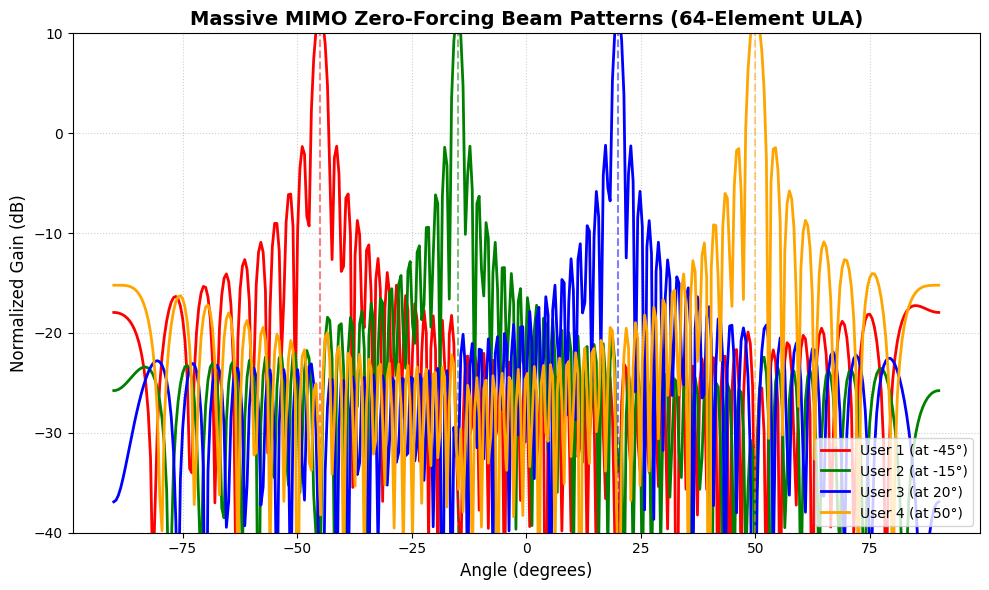

Massive MIMO radiation patterns visualized successfully.


In [3]:
# --- 1. Compute Beam Patterns for All 4 Users ---
patterns = []
for k in range(K_users):
    patterns.append(get_beam_pattern(W_zf[:, k], test_angles, N_t, d))

# --- 2. Plotting the Radiation Patterns ---
plt.figure(figsize=(10, 6))

colors = ['r', 'g', 'b', 'orange']
for k in range(K_users):
    plt.plot(test_angles, patterns[k], label=f'User {k+1} (at {user_angles[k]}°)', color=colors[k], lw=2)
    # Highlight the target direction with a dashed line
    plt.axvline(user_angles[k], color=colors[k], linestyle='--', alpha=0.5)

plt.title('Massive MIMO Zero-Forcing Beam Patterns (64-Element ULA)', fontsize=14, weight='bold')
plt.xlabel('Angle (degrees)', fontsize=12)
plt.ylabel('Normalized Gain (dB)', fontsize=12)
plt.ylim(-40, 10)  # Standard dynamic range for antenna patterns
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('mimo_beam_pattern.png', dpi=300)
plt.show()

print("Massive MIMO radiation patterns visualized successfully.")